In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
data=pd.read_csv('C:/Users/Saee Beri/OneDrive/Desktop/Msc Datascience/Sem 2/diabetes.csv')
df=pd.DataFrame(data)
print(df.head())
print("\n")
print(df.shape)
print(df.dtypes)
print(df.columns)

FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/Saee Beri/OneDrive/Desktop/Msc Datascience/Sem 2/diabetes.csv'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
data=pd.read_csv('C:/Users/Saee Beri/OneDrive/Desktop/Msc Datascience/Sem 2/ML Assignments/diabetes.csv')
df=pd.DataFrame(data)
print(df.head())
print("\n")
print(df.shape)
print(df.dtypes)
print(df.columns)

   preg  plas  pres  skin  insu  mass   pedi  age            class
0     6   148    72    35     0  33.6  0.627   50  tested_positive
1     1    85    66    29     0  26.6  0.351   31  tested_negative
2     8   183    64     0     0  23.3  0.672   32  tested_positive
3     1    89    66    23    94  28.1  0.167   21  tested_negative
4     0   137    40    35   168  43.1  2.288   33  tested_positive


(768, 9)
preg       int64
plas       int64
pres       int64
skin       int64
insu       int64
mass     float64
pedi     float64
age        int64
class     object
dtype: object
Index(['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age', 'class'], dtype='object')


In [5]:
label_encoders = {}
for column in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

X = data.drop(columns=['class']) 
y = data['class']
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [6]:
x = df.iloc[:,:-2]
y = df.iloc[:,-1:]

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [7]:
X_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
clf = DecisionTreeClassifier()
clf.fit(x_train,y_train)

y_pred = clf.predict(x_test)
print(classification_report(y_test, y_pred))

c:\Users\Saee Beri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 8 features, but DecisionTreeClassifier is expecting 7 features as input.

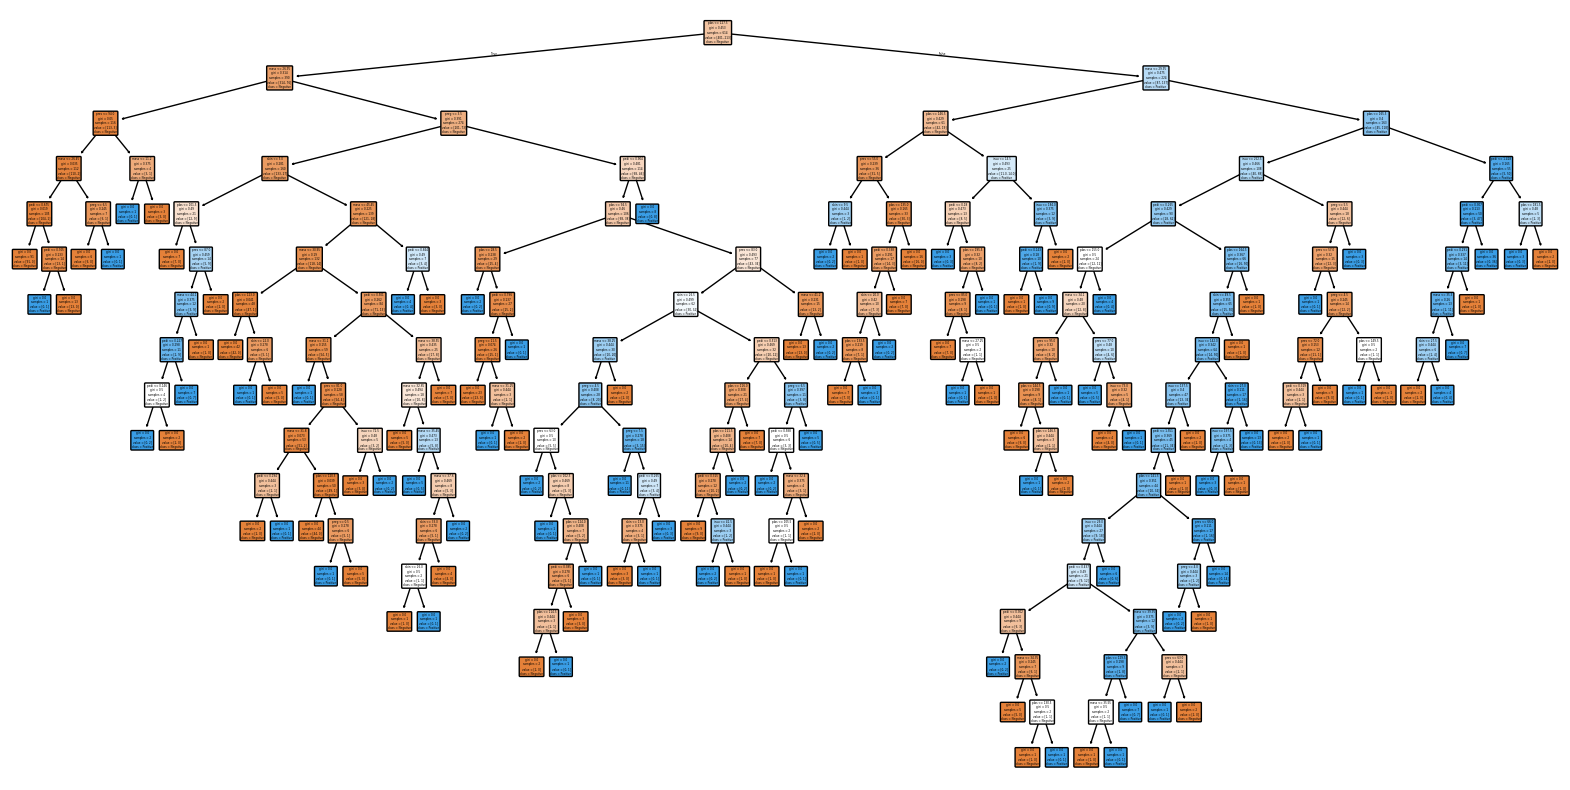

In [8]:
plt.figure(figsize=(20, 10))
plot_tree(clf, feature_names=x.columns, class_names=["Negative", "Positive"], filled=True, rounded=True)
plt.show()

In [10]:
y_pred_initial = dt.predict(x_test)
initial_accuracy = accuracy_score(y_test, y_pred_initial)
print("Initial Accuracy (Before Pruning):", initial_accuracy)

c:\Users\Saee Beri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 8 features, but DecisionTreeClassifier is expecting 7 features as input.

In [11]:
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, n_jobs=-1)
grid_search.fit(x_train, y_train)
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

Best Parameters from GridSearchCV: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}


In [13]:
dt_best = DecisionTreeClassifier(**grid_search.best_params_, random_state=42)
dt_best.fit(x_train, y_train)
y_pred_prepruned = dt_best.predict(x_test)
prepruned_accuracy = accuracy_score(y_test, y_pred_prepruned)
print("Accuracy After Pre-Pruning:", prepruned_accuracy)

c:\Users\Saee Beri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 8 features, but DecisionTreeClassifier is expecting 7 features as input.

In [14]:
path = dt_best.cost_complexity_pruning_path(x_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]
accuracies = []
for alpha in ccp_alphas:
    dt_pruned = DecisionTreeClassifier(**grid_search.best_params_, ccp_alpha=alpha, random_state=42)
    dt_pruned.fit(x_train, y_train)
    y_pred = dt_pruned.predict(x_test)
    accuracies.append(accuracy_score(y_test, y_pred))

c:\Users\Saee Beri\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


ValueError: X has 8 features, but DecisionTreeClassifier is expecting 7 features as input.

ValueError: x and y must have same first dimension, but have shapes (7,) and (0,)

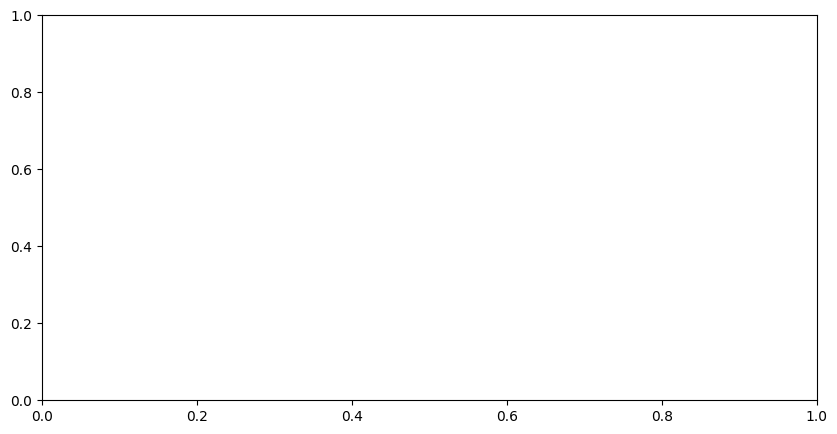

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(ccp_alphas, accuracies, marker='o', linestyle='--')
plt.xlabel('Alpha')
plt.ylabel('Accuracy')
plt.title('Post-Pruning: Accuracy vs Alpha')
plt.show()

In [14]:
dt_final = DecisionTreeClassifier(**grid_search.best_params_, ccp_alpha=ccp_alphas[np.argmax(accuracies)], random_state=42)
dt_final.fit(x_train, y_train)
y_pred_final = dt_final.predict(x_test)
final_accuracy = accuracy_score(y_test, y_pred_final)
print("Final Model Accuracy After Post-Pruning:", final_accuracy)

ValueError: attempt to get argmax of an empty sequence